# <center> Numerical methods and applications for<br><br> Elliptic Partial Differential Equations I.</center>

## <center>Imre Fekete</center>
### <center> Department of Applied Analysis and Computational Mathematics
</center>
<img src="cimer2.jpg" width="400">
<br>
<br>
<br>
<br>

### General information:
+ <span class="fa fa-building-o"></span> Southern Bldg. 3.702
+ Website: <a href="http://imrefekete.web.elte.hu/" target="_blank"> http://imrefekete.web.elte.hu/</a>
+ Office hours: TBA 
+ All of the course material can be found at the  <a href=""> Github repo</a>
<br><br>

### Evaluation:
+ 2 big assignments (FD, MG)
+ Regular weekly assignments (theoretical and/or programming problems)
+ [Extra] means option earning additional points 
<br><br>

### Literature:
#### Lecture Notes in Hungarian (Eötvös Loránd University)
+ <a href="http://web.cs.elte.hu/~karatson/pdnm_vegleges_2013.pdf">Horváth Róbert, Izsák Ferenc, Karátson János: Parciális differenciálegyenletek numerikus módszerei számítógépes alkalmazásokkal </a>
+ <a href="http://web.cs.elte.hu/~faragois/jegyzet_Szeged.pdf">Faragó István: Numerikus modellezés és közönséges differenciálegyenletek numerikus megoldási módszerei </a>
+ Stoyan Gisbert, Takó Galina: Numerikus módszerek 3.

#### Introductory MATLAB
+ Cleve B. Moler: Numerical Computing with MATLAB
+ Stoyan Gisbert: MATLAB (in Hungarian)

#### Recommended and Further literature
+ William L. Briggs, Van Emden Henson, and Steve F. McCormick: A multigrid tutorial
+ Kurutzné Kovács Márta, Scharle Péter: A végeselem-módszer egyszerű elemei és elemcsaládjai (in Hungarian)
+ A.J.M. Ferreira: MATLAB Codes for Finite Element Analysis, Solids and Structures
+ Uri M. Ascher , Robert M. M. Mattheij, and Robert D. Russell: Numerical Solution of Boundary Value Problems for Ordinary Differential Equations




### Three wishes:

<br>
<br>


<div style="width:870 px">
<div style="float:left"><img src="questions.jpg" width="450" title="Please ask me if something is not clear!"/></div>
<div style="float:left"><img src="practice.jpg" width="400" title="Practice makes perfect!"/></div>
<div style="float:left"><img src="positive.jpg" width="870" title="A good atmosphere helps a lot!"/></div> 
<div style="clear:both"></div>
</div>   
<br>
<br>

### What are we going to learn in this semester?

<br>
<br>


<div style="width:870 px">
<div style="float:left"><img src="laplace.png" width="500" title="Five point stencil (Finite difference Methods FDM)"/></div>
<div style="float:left"><img src="multigrid.jpg" width="570" title="Multigrid (MG): V-cycle"/></div>
<div style="float:left"><img src="FEM.png" width="270" title="Finite Element Method (FEM)"/></div> 
<div style="clear:both"></div>
</div>   


<br>
<br>
## <center>Introduction</center>


### Motivation and theoretical background in a nutshell
<br>
Mathematical models of physical phenomena where we neglect the time variable (steady state)

<br>
Let's start with the classical heat conduction (thermal conduction) model
$$c\rho \frac{\partial u}{\partial t}=\mathrm{div}(k\mathrm{grad}u)+f(x),$$

where 
+ $u$ is the temperature
+ $\rho$ is the density of heat conductivity media
+ $k$ is the material's heat conductivity
+ $f$ is the heat sources' density. 

<br>

What is going to happen if variable $u$ is independent from time variable $t$? We will have steady state, i.e.

$$0=\mathrm{div}(k\mathrm{grad}u)+f(x)$$

Potential physical meanings: <br>

(a) Flow of a fluid through a porous medium (<a href="https://en.wikipedia.org/wiki/Darcy%27s_law" target="_blank">Darcy's law</a>)<br>
(b) Governing the transport of mass through diffusive means (<a href="https://en.wikipedia.org/wiki/Fick%27s_laws_of_diffusion" target="_blank">Fick's law</a>)<br><br>

An important special case of (b) when $k=const$. This is the most basic elliptic equation the so-called $\it{Poisson-equation}$
<br><br>

$$\Delta u+f(x)=0$$

If $f=0$ then it is called $\it{Laplace-equation}$. The above equation has more physical meanings. If $k$ is the dielectric constant, $f$ is the charge density, then $u$ gives the potential of the electrostatic field. It is the reason then sometimes the equation is also called $\it{potential\ equation}$.
<br>
<br>
Our last example when we cas model twisting thin rods by using the Poisson equation

$$\Delta \Phi=-1,\quad (x_1,x_2)\in\Omega,\quad \Phi|_{\Gamma}=0,$$

where 
+ $\Omega$ is the cross section of the rod
+ $\Gamma$ is the boundary of $\Omega$ 
+ $\Phi$ is the auxilary function
<br>

<br>
Further technical details regarding the theoretical background can be presented during the seminar.
<br>

<br>
## <center>Problem Sheet #1</center>

### Two-point Boundary Value Problems (BVPs) in 1D
<br>

<div style="float:left"><img src="ZeroStabNTNU.png" width="970" title="General discretization scheme, based on Gustaf Söderlind's figure"/></div> 
<br>

#### Discretizations and Dirichlet boundary condition
<br>

<b>Problem 1.</b> Consider the following two-point BVP

\begin{cases}
-u''(x)=1,\quad x\in(0,\pi/4)\\
u(0)=1\\
u(\pi/4)=2
\end{cases}

(a) Apply the standar second order finite difference scheme for the second derivative. Make a plot about the numerical and the true solutions.

<br>


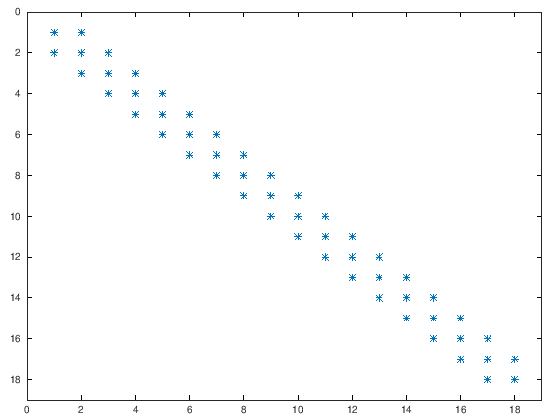

In [1]:
a=0; b=pi/4; %interval
alpha=1; beta=2; %boundary values
N=16;
h=(b-a)/(N+1);
e=ones(N+2,1);
A_h=(1/h^2)*spdiags([-e 2*e -e],[-1,0,1],N+2,N+2);
spy(A_h)

y =

   1.0000
   1.1416
   1.2755
   1.4019
   1.5206
   1.6317
   1.7352
   1.8311
   1.9194
   2.0000



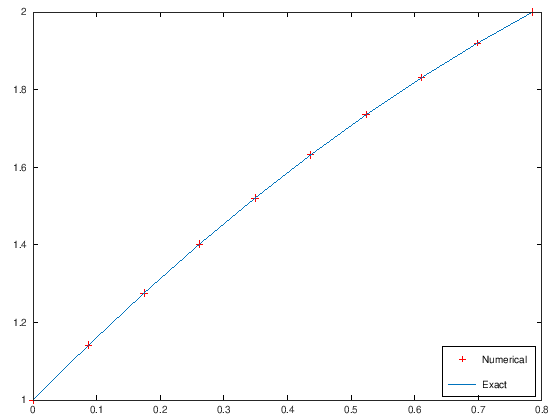

In [4]:
a=0; b=pi/4; %interval
alpha=1; beta=2; %boundary values
% Grid
N=8;
h=(b-a)/(N+1);
% A_h
e=ones(N+2,1);
A_h=(1/h^2)*spdiags([-e 2*e -e],[-1,0,1],N+2,N+2);
A_h(1,1)=1; A_h(1,2)=0;
A_h(N+2,N+1)=0; A_h(N+2,N+2)=1;
%Right hand side function f 
f=ones(N+2,1); f(1)=alpha; f(N+2)=beta;
% Numerical and exact solutions
y=A_h\f
x=linspace(a,b,N+2)';
exact=-0.5*x.^2+(4/pi+pi/8)*x+1;
plot(x,y,'r+',x,exact)
legend('Numerical','Exact','Location','southeast')

<br>
(b) Modify the previous code in the reduced system's sense. Measure the global error in the maximum norm! What can we experience by increasing the number of the subintervals?
<br>

norm_max =    2.8866e-15


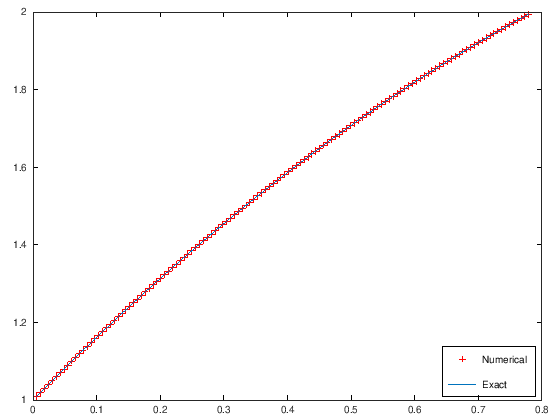

In [7]:
a=0; b=pi/4; %interval
alpha=1; beta=2; %boundary values
% Grid
N=128;
h=(b-a)/(N+1);
% A_h
e=ones(N,1);
A_h=(1/h^2)*spdiags([-e 2*e -e],[-1,0,1],N,N);
%Right hand side function f
f=ones(N,1); f(1)=1+alpha/h^2; f(N)=1+beta/h^2;
% Numerical and exact solutions
y=A_h\f;
x=linspace(a+h,b-h,N)';
exact=-0.5*x.^2+(4/pi+pi/8)*x+1;
plot(x,y,'r+',x,exact)
legend('Numerical','Exact','Location','southeast')
norm_max=norm(y-exact,'inf')

<b>Problem 2.</b> Consider the following two-point BVP


\begin{cases}
u''(x)-u(x)=0,\quad x\in(0,1)\\
u(0)=0\\
u(1)=1
\end{cases}

(a) Apply the techniques from Problem 1. Measure the global error in the maximum norm, 1-norm and 2-norm! What can we experience by increasing the number of the subintervals?

norm_max =    4.05623295784974e-06
norm_1 =    2.63314551805471e-06
norm_2 =    2.91047320769278e-06


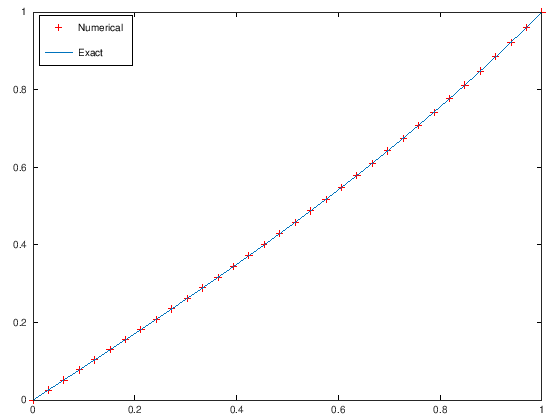

In [10]:
format long
a=0; b=1; %interval
alpha=0; beta=1; %boundary values
% Grid
N=32;
h=(b-a)/(N+1);
% A_h
e=ones(N+2,1);
A_h=(1/h^2)*spdiags([e -2*e-h^2*e e],[-1,0,1],N+2,N+2);
A_h(1,1)=1; A_h(1,2)=0;
A_h(N+2,N+1)=0; A_h(N+2,N+2)=1;
% Rigth hand side function f
f=zeros(N+2,1); f(1)=alpha; f(N+2)=beta;
% Numerical and exact solutions
y=A_h\f;
x=linspace(a,b,(N+2))';
exact=sinh(x)/sinh(1);
% Norms
norm_max=norm(y-exact,'inf')
norm_1=h*sum(abs(y-exact))
norm_2=(h*sum(abs(y-exact).^2))^(1/2)
plot(x,y,'r+',x,exact)
legend('Numerical','Exact','Location','northwest')

(b) [Assignment] Modify the previous code in the reduced systems' sense.

norm_max =    1.52940269765311e-05
norm_1 =    9.89285203871114e-06
norm_2 =    1.09635381786869e-05


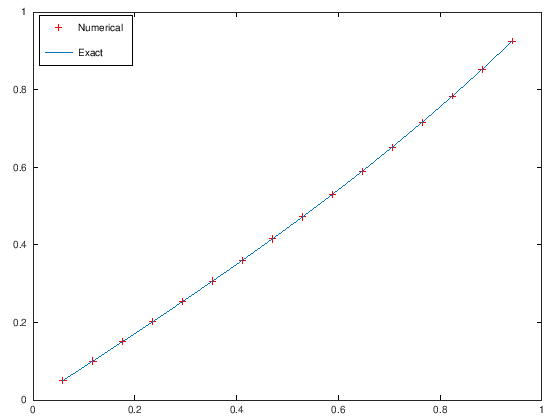

<br>
#### Neumann boundary condition
<br>

<b>Problem 3.</b> Let us consider the following problem

\begin{cases}
u''(x)=e^x,\quad x\in(0,1)\\
u'(0)=1\\
u(1)=e
\end{cases}

(a) Let us apply the first and second approaches approximating the Neumann boundary. Measure the global error in the maximum normm. What can we experience? Plot the numerical and the true solutions in the same figure.

<br>
(b) [Assignment] Apply the third approach approximating the Neumann boundary. Plot the numerical and the true solutions in the same figure.

norm_max =  0.0153595184905693


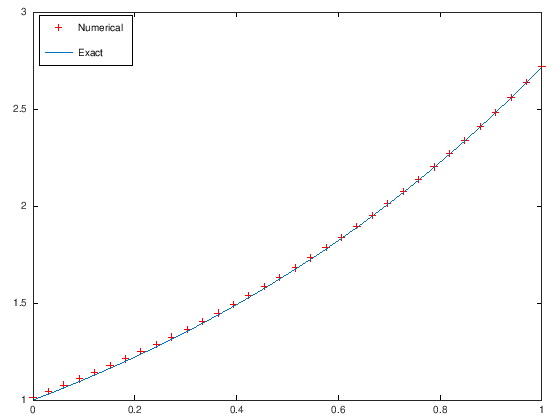

In [24]:
% First approach
a=0; b=1; %interval
alpha=1; beta=exp(1); %boundary values
% Grid
N=32;
h=(b-a)/(N+1);
% A_h
e=ones(N+2,1);
A_h=(1/h^2)*spdiags([e -2*e e],[-1,0,1],N+2,N+2);
A_h(1,1)=-1/h; A_h(1,2)=1/h;
A_h(N+2,N+1)=0; A_h(N+2,N+2)=1;
% Right hand side function f
x=linspace(a,b,N+2)';
f=exp(x); f(1)=alpha; f(N+2)=beta;
% Numerical and exact solutions
y=A_h\f;
exact=exp(x);
norm_max=norm(y-exact,'inf')
plot(x,y,'r+',x,exact)
legend('Numerical','Exact','Location','northwest')

norm_max =  0.00279528392924178


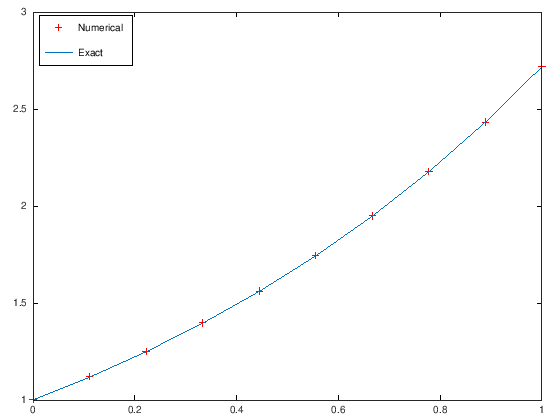

In [26]:
% Second approach
a=0; b=1; %interval
alpha=1; beta=exp(1); %boundary values
% Grid
N=32;
h=(b-a)/(N+1);
% A_h
e=ones(N+2,1);
A_h=(1/h^2)*spdiags([e -2*e e],[-1,0,1],N+2,N+2);
A_h(1,1)=-1/h; A_h(1,2)=1/h;
A_h(N+2,N+1)=0; A_h(N+2,N+2)=1;
% Right hand side function f
x=linspace(a,b,N+2)';
f=exp(x); f(1)=alpha+h/2*exp(a); f(N+2)=beta;
% Numerical and exact solutions
y=A_h\f;
exact=exp(x);
norm_max=norm(y-exact,'inf')
plot(x,y,'r+',x,exact)
legend('Numerical','Exact','Location','northwest')

norm_max =    6.56436667041405e-05


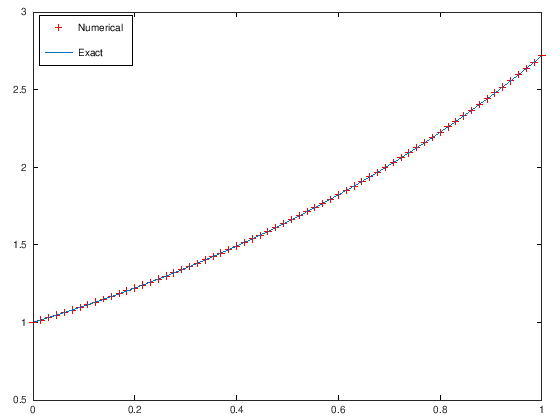

In [27]:
% Assignment - Third approach